In [954]:
import utils
import numpy as np
import pandas as pd
import os
from scipy.stats import chisquare

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)

In [955]:
# Make output folder
output_dir = os.path.join('..','plots','behavioural_pilot', 'objective_performance')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [956]:
# Preparation
experiment_output_path = os.path.join('..', '..', 'phd_1_task', 'experiment_output', 'behavioural_files')
experiment_output_path = os.path.join('..', '..', 'phd_1_task', 'experiment_output_verena')

In [957]:
unique_subject_ids = list(range(1, 50))
unique_sessions = [1]

recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(experiment_output_path, unique_subject_ids, unique_sessions)

sub-046 did not complete session-01
sub-047 did not complete session-01
sub-048 did not complete session-01
sub-049 did not complete session-01


In [958]:
print(recent_results)

['../../phd_1_task/experiment_output_verena/experiment_output_sub-001_session-01_2024-04-10_13-37-11.csv', '../../phd_1_task/experiment_output_verena/experiment_output_sub-002_session-01_2024-04-10_13-37-11.csv', '../../phd_1_task/experiment_output_verena/experiment_output_sub-003_session-01_2024-04-10_13-37-11.csv', '../../phd_1_task/experiment_output_verena/experiment_output_sub-004_session-01_2024-04-10_13-37-11.csv', '../../phd_1_task/experiment_output_verena/experiment_output_sub-005_session-01_2024-04-10_13-37-11.csv', '../../phd_1_task/experiment_output_verena/experiment_output_sub-006_session-01_2024-04-10_13-37-11.csv', '../../phd_1_task/experiment_output_verena/experiment_output_sub-007_session-01_2024-04-10_13-37-11.csv', '../../phd_1_task/experiment_output_verena/experiment_output_sub-008_session-01_2024-04-10_13-37-11.csv', '../../phd_1_task/experiment_output_verena/experiment_output_sub-009_session-01_2024-04-10_13-37-11.csv', '../../phd_1_task/experiment_output_verena/ex

In [959]:
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
if 'verena' in experiment_output_path:
    combined_results_dataframe = combined_results_dataframe[~combined_results_dataframe['stimuli_type'].isin([2, 4])]

print(combined_results_dataframe)

       trial  emotional_cue_time response  response_time      RT_s  \
1          2         2373.745318       up    2374.347255  0.601937   
3          4         2384.333049     down            NaN       NaN   
4          5         2390.135470       up    2390.675442  0.539971   
7          8         2409.543537       up    2410.018352  0.474816   
10        11         2426.934122       up    2427.767840  0.833718   
...      ...                 ...      ...            ...       ...   
21591    472        20717.742857       up   20718.176074  0.433217   
21592    473        20722.627503       up   20723.506187  0.878684   
21594    475        20733.932854       up   20734.677275  0.744421   
21596    477        20744.237096       up   20744.707587  0.470491   
21599    480        20763.427636       up   20763.906928  0.479292   

       probability_condition  stimuli_type  iti  face_type  \
1                         50             1  3.0          9   
3                         50       

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [960]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

### Make additional column for congruency

In [961]:
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)
print(combined_results_dataframe[['stimuli_type','probability_condition','congruency']])

       stimuli_type  probability_condition   congruency
1                 1                     50    undefined
3                 1                     50    undefined
4                 3                     50    undefined
7                 3                     50    undefined
10                3                     50    undefined
...             ...                    ...          ...
21591             3                     80  incongruent
21592             1                     80    congruent
21594             3                     80  incongruent
21596             1                     80    congruent
21599             3                     80  incongruent

[10800 rows x 3 columns]


In [962]:
# Turns the objective values into boolean ones
mapping = {'True': 1, 'False': 0, 'Even': 0, 'Late': 0}
#pd.options.display.max_rows = None

combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'].astype('int')

# Statistics
Start by checking if the objectively correct answers significantly differ from chance

In [963]:
# Filter out trials with 50% reward probability and without responses
stats_dataframe = combined_results_dataframe.drop(combined_results_dataframe[(combined_results_dataframe.probability_condition == 50) | (combined_results_dataframe.objectively_correct == 'Late')].index, inplace=False)
# Calculate the total number of successes and the total number of trials
total_successes = stats_dataframe['objectively_correct_boolean'].sum()
total_trials = len(stats_dataframe)

# Calculate expected successes and failures if each trial has a 50% chance of success
expected_successes = total_trials * 0.5
expected_failures = total_trials * 0.5

# Perform the chi-square goodness of fit test
chi2_stat, p_value = chisquare([total_successes, total_trials - total_successes],
                               f_exp=[expected_successes, expected_failures])

print(chi2_stat, p_value)

1059.0101222071348 2.6788888686292207e-232


In [964]:
# Multiply the boolean response by 100 to get percentages, can only do this after the stats
combined_results_dataframe['objectively_correct_boolean'] *= 100

# Objectively correct answer binned after every switch

In [965]:
# Create a dataframe with objectively correct responses up to 12 trials after switch
unique_stimuli_types = combined_results_dataframe['stimuli_type'].unique()
row_index = 0

objectively_correct_answers_per_switch_block = pd.DataFrame()

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]
        
        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        
        # Filter out trials with 50% reward probability and without responses
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.drop(combined_results_grouped_dataframe[(combined_results_grouped_dataframe.probability_condition == 50) | (combined_results_grouped_dataframe.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.reset_index()
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()
        print(f'{index_stimuli}, {index_subject_id}, {switches_reward}')
        
        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = dataframe_containing_groups_filtered.iloc[values:values+11]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns={0: 'subject_id', 1: 'stimuli_type', 2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6, 9: 7, 10: 8, 11: 9, 12: 10, 13: 11, 14: 12})

1, sub-001, [0, 15, 30, 48, 60, 72]
1, sub-002, [0, 15, 30, 48, 60, 72]
1, sub-003, [0, 15, 30, 48, 60, 78]
1, sub-004, [0, 15, 30, 42, 60, 72]
1, sub-005, [0, 15, 30, 42, 60, 78]
1, sub-006, [0, 15, 30, 42, 60, 78]
1, sub-007, [0, 12, 30, 48, 60, 75]
1, sub-008, [0, 12, 30, 45, 60, 78]
1, sub-009, [0, 12, 30, 45, 60, 72]
1, sub-010, [0, 12, 30, 48, 60, 75]
1, sub-011, [0, 18, 30, 45, 60, 78]
1, sub-012, [0, 12, 30, 45, 60, 72]
1, sub-013, [0, 18, 30, 48, 60, 75]
1, sub-014, [0, 18, 30, 45, 60, 72]
1, sub-015, [0, 12, 30, 45, 60, 78]
1, sub-016, [0, 12, 30, 42, 60, 75]
1, sub-017, [0, 12, 30, 45, 60, 72]
1, sub-018, [0, 18, 30, 45, 60, 78]
1, sub-019, [0, 18, 30, 42, 60, 75]
1, sub-020, [0, 12, 30, 45, 60, 64, 65, 66, 68, 69, 71, 74, 75, 76, 79, 86, 87, 89, 90]
1, sub-021, [0, 12, 30, 45, 60, 72]
1, sub-022, [0, 18, 30, 48, 60, 75]
1, sub-023, [0, 12, 30, 45, 60, 78]
1, sub-024, [0, 18, 30, 45, 60, 78]
1, sub-025, [0, 15, 30, 48, 60, 72]
1, sub-026, [0, 15, 30, 48, 60, 72]
1, sub-027, 

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_1995/265265751.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_1995/265265751.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld

3, sub-020, [0, 18, 30, 45, 60, 61, 65, 71, 72, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87]
3, sub-021, [0, 18, 30, 48, 60, 75]
3, sub-022, [0, 18, 30, 45, 60, 78]
3, sub-023, [0, 12, 30, 42, 60, 75]
3, sub-024, [0, 12, 30, 45, 60, 72]
3, sub-025, [0, 12, 30, 45, 60, 72]
3, sub-026, [0, 12, 30, 45, 60, 72]
3, sub-027, [0, 18, 30, 45, 60, 78]
3, sub-028, [0, 18, 30, 45, 60, 72]
3, sub-029, [0, 18, 30, 45, 60, 72]
3, sub-030, [0, 12, 30, 48, 60, 75]
3, sub-031, [0, 18, 30, 45, 60, 72]
3, sub-032, [0, 12, 30, 48, 60, 75]
3, sub-033, [0, 12, 30, 45, 60, 78]
3, sub-034, [0, 18, 30, 45, 60, 72]
3, sub-035, [0, 18, 30, 45, 60, 72]
3, sub-036, [0, 18, 30, 42, 60, 75]
3, sub-037, [0, 15, 30, 42, 60, 78]
3, sub-038, [0, 15, 30, 48, 60, 72]
3, sub-039, [0, 15, 30, 48, 60, 72]
3, sub-040, [0, 15, 30, 48, 60, 72]
3, sub-041, [0, 15, 30, 48, 60, 72]
3, sub-042, [0, 15, 30, 42, 60, 72]
3, sub-043, [0, 18, 30, 45, 60, 72]
3, sub-044, [0, 18, 30, 45, 60, 72]
3, sub-045, [0, 12, 30, 42, 60, 75]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_1995/265265751.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_1995/265265751.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld

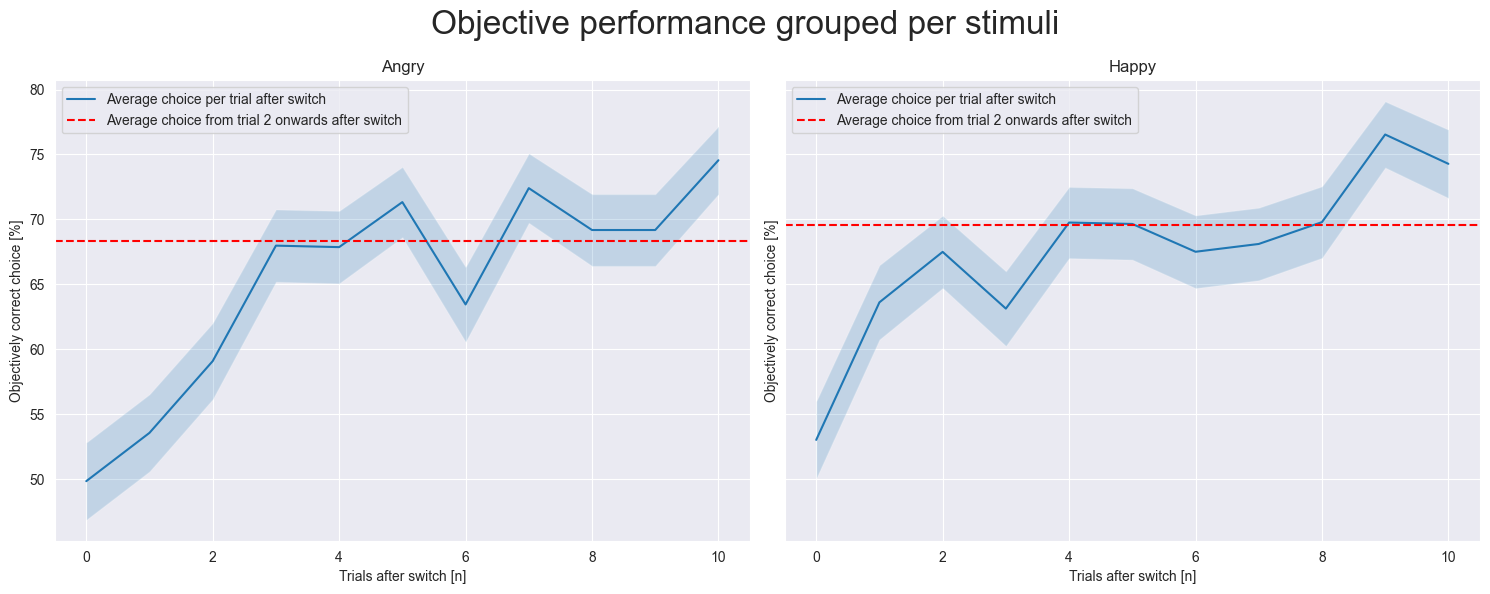

In [966]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped per stimuli', fontsize=24, y=0.982)

stimuli_types_list = ['Angry', 'Happy']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = np.arange(len(means.columns))
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_per_stimuli_0-12.pdf'))
plt.show()

## objectively correct answers without binning
Now we'll look at the objectively correct answers in a sequential manner, so without binning them based on switches in reward contingencies.
Plot probability of correct response on Y-axis to trials on X-axis

In [967]:
# Take the mean from all 12 trials after each switch
trials_after_switch_to_plot = list(range(0,11))
intermediate_dataframe = objectively_correct_answers_per_switch_block
intermediate_dataframe['switch_number'] = intermediate_dataframe.groupby(['subject_id','stimuli_type']).cumcount()
print(intermediate_dataframe)

# Preparation for loop
unique_switches = intermediate_dataframe['switch_number'].unique()
column_names = ['stimuli_type', 'switch'] + trials_after_switch_to_plot
objectively_correct_answers_averaged_per_switch_block = pd.DataFrame(columns = column_names)

# Loop through each stimulus and switch type
for index_stimuli, value_stimuli in enumerate(unique_stimuli_types):
    for index_switch, value_switch in enumerate(unique_switches):
        filtered_dataframe = intermediate_dataframe[(intermediate_dataframe['stimuli_type'] == value_stimuli) & (intermediate_dataframe['switch_number'] == value_switch)]
        list_with_averages = [value_stimuli, value_switch] + (filtered_dataframe[trials_after_switch_to_plot].mean()).to_list()
        objectively_correct_answers_averaged_per_switch_block.loc[len(objectively_correct_answers_averaged_per_switch_block)] = list_with_averages

    subject_id  stimuli_type    0      1      2      3      4      5      6  \
0      sub-001             1  100    0.0    0.0    0.0    0.0  100.0  100.0   
1      sub-001             1    0    0.0    0.0  100.0    0.0  100.0  100.0   
2      sub-001             1    0  100.0  100.0  100.0  100.0  100.0  100.0   
3      sub-001             1  100  100.0  100.0  100.0  100.0  100.0  100.0   
4      sub-001             1  100  100.0  100.0  100.0  100.0  100.0  100.0   
..         ...           ...  ...    ...    ...    ...    ...    ...    ...   
561    sub-045             3  100  100.0    0.0  100.0  100.0  100.0    0.0   
562    sub-045             3  100  100.0  100.0  100.0  100.0  100.0  100.0   
563    sub-045             3    0  100.0  100.0  100.0  100.0  100.0  100.0   
564    sub-045             3    0    0.0  100.0  100.0  100.0  100.0  100.0   
565    sub-045             3    0    0.0    0.0  100.0  100.0  100.0  100.0   

         7      8      9     10  switch_number  
0 

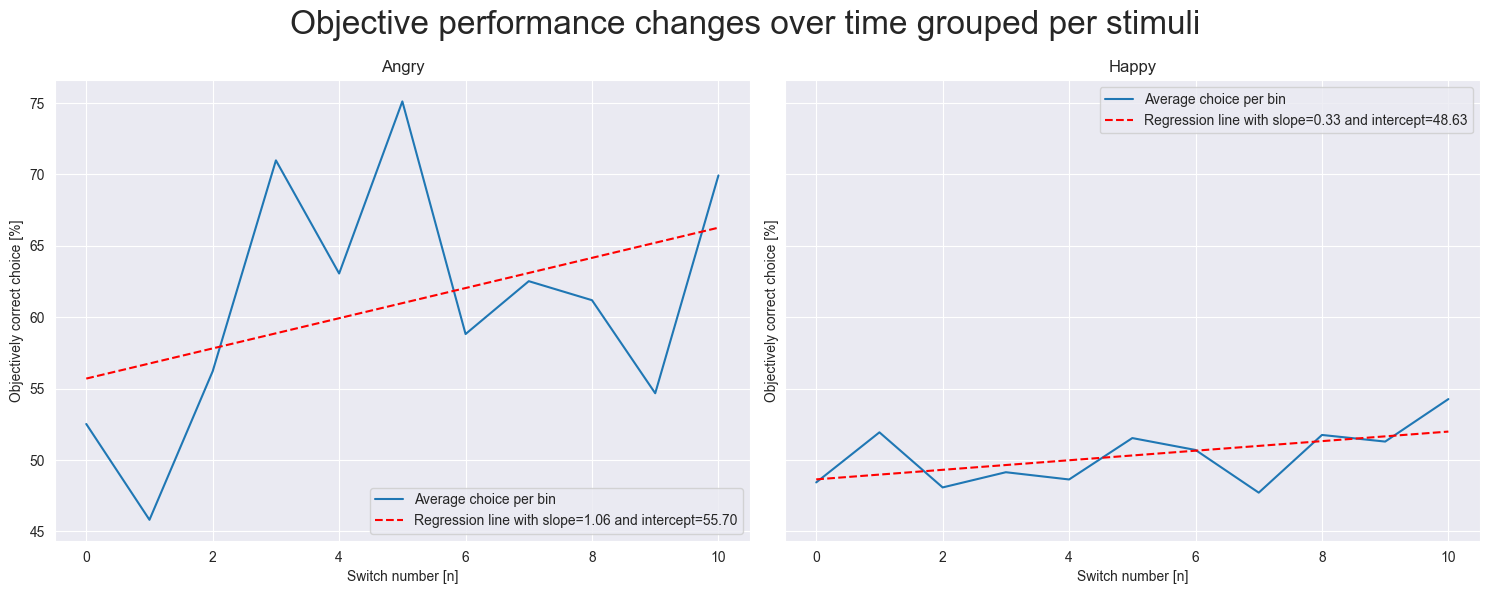

In [968]:
# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance changes over time grouped per stimuli', fontsize=24, y=0.982)

for index_stimuli, value_stimuli in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    filtered_dataframe = objectively_correct_answers_averaged_per_switch_block[objectively_correct_answers_averaged_per_switch_block['stimuli_type'] == value_stimuli]
    filtered_dataframe = filtered_dataframe.drop(['stimuli_type', 'switch'], axis=1)

    timepoints = [int(col) for col in filtered_dataframe.columns]
    averages = filtered_dataframe.mean()
    a, b = np.polyfit(timepoints, averages, 1)
    regression_line = [i * a + b for i in timepoints]

    axs[index_stimuli].plot(averages, label='Average choice per bin')
    axs[index_stimuli].plot(timepoints, regression_line, color='r', linestyle='--', label=f'Regression line with slope={a:.2f} and intercept={b:.2f}')
    axs[index_stimuli].set_title(stimuli_types_list[index_stimuli])
    axs[index_stimuli].set_xlabel('Switch number [n]')
    axs[index_stimuli].set_ylabel('Objectively correct choice [%]')
    axs[index_stimuli].legend()
    axs[index_stimuli].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_changes_over_time_grouped_per_stimuli.pdf'))
plt.show()

# Objectively correct answers binned around a switch
Starting 12 trials before the switch and ending 4 after.

In [969]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()

plot_range = list(range(-10, 5))

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]

        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        # Filter out trials with 50% reward probability
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()

        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = combined_results_grouped_dataframe.iloc[values-10:values+5]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns={0: 'subject_id', 1: 'stimuli_type', 2: -10, 3: -9, 4: -8, 5: -7, 6: -6, 7: -5, 8: -4, 9: -3, 10: -2, 11: -1, 12: 0, 13: 1, 14: 2, 15: 3, 16: 4})

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_1995/3708134271.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_1995/3708134271.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/

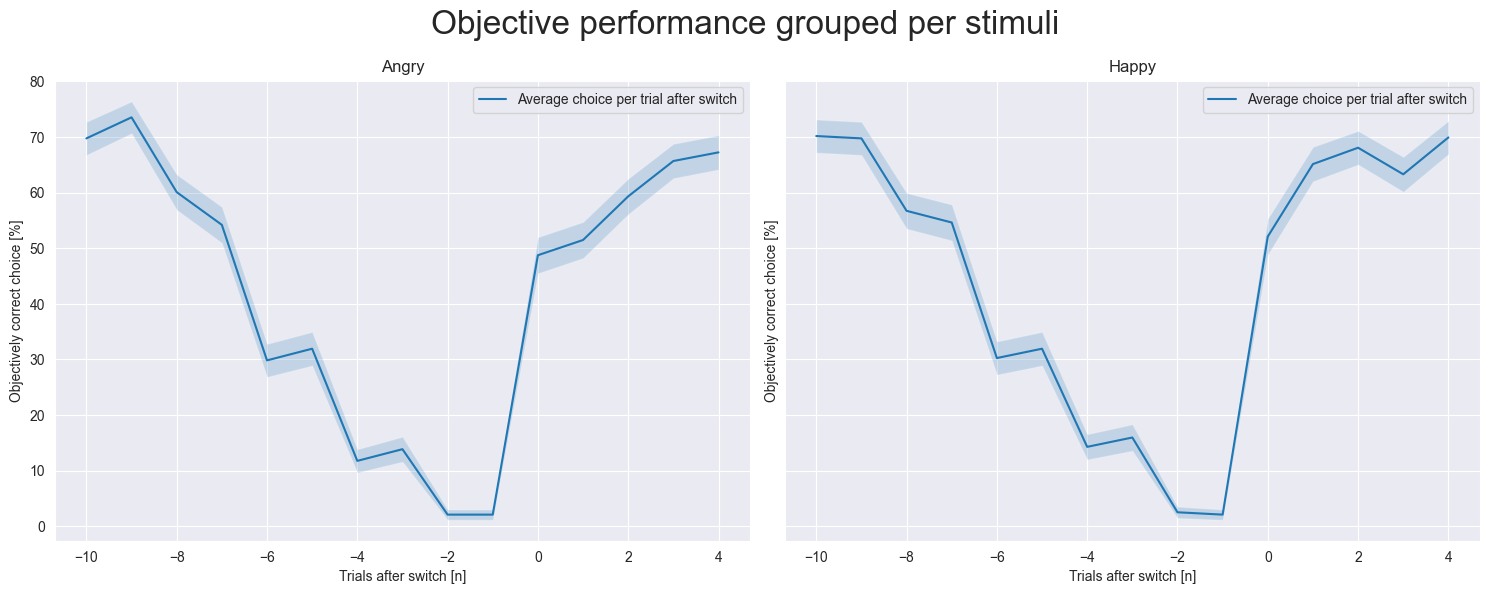

In [970]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped per stimuli', fontsize=24, y=0.982)

stimuli_types_list = ['Angry', 'Happy']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    #axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_per_stimuli_12-4.pdf'))
plt.show()

# Objectively correct answers binned around a switch
Starting 4 trials before the switch and ending 12 after.

In [971]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()

plot_range = list(range(-4, 11))
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: -4, 3: -3, 4: -2, 5: -1, 6: 0, 7: 1, 8: 2, 9: 3, 10: 4, 11: 5, 12: 6, 13: 7, 14: 8, 15: 9, 16: 10}

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]

        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        # Filter out trials with 50% reward probability
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()

        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = combined_results_grouped_dataframe.iloc[values+min(plot_range):values+max(plot_range)+1]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns=mapping)
print(objectively_correct_answers_per_switch_block)

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_1995/1147918485.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_1995/1147918485.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/

    subject_id  stimuli_type   -4   -3   -2   -1      0      1      2      3  \
0      sub-001             1  NaN  NaN  NaN  NaN    NaN    NaN    NaN    NaN   
1      sub-001             1  0.0  0.0  0.0  0.0    0.0    0.0    0.0  100.0   
2      sub-001             1  0.0  0.0  0.0  0.0    0.0  100.0  100.0  100.0   
3      sub-001             1  0.0  0.0  0.0  0.0  100.0  100.0  100.0  100.0   
4      sub-001             1  0.0  0.0  0.0  0.0  100.0  100.0  100.0  100.0   
..         ...           ...  ...  ...  ...  ...    ...    ...    ...    ...   
561    sub-045             3  0.0  0.0  0.0  0.0  100.0  100.0    0.0  100.0   
562    sub-045             3  0.0  0.0  0.0  0.0  100.0  100.0  100.0  100.0   
563    sub-045             3  0.0  0.0  0.0  0.0    0.0  100.0  100.0  100.0   
564    sub-045             3  0.0  0.0  0.0  0.0    0.0    0.0  100.0  100.0   
565    sub-045             3  0.0  0.0  0.0  0.0    0.0    0.0    0.0  100.0   

         4      5      6      7      8 

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_1995/1147918485.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_1995/1147918485.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/

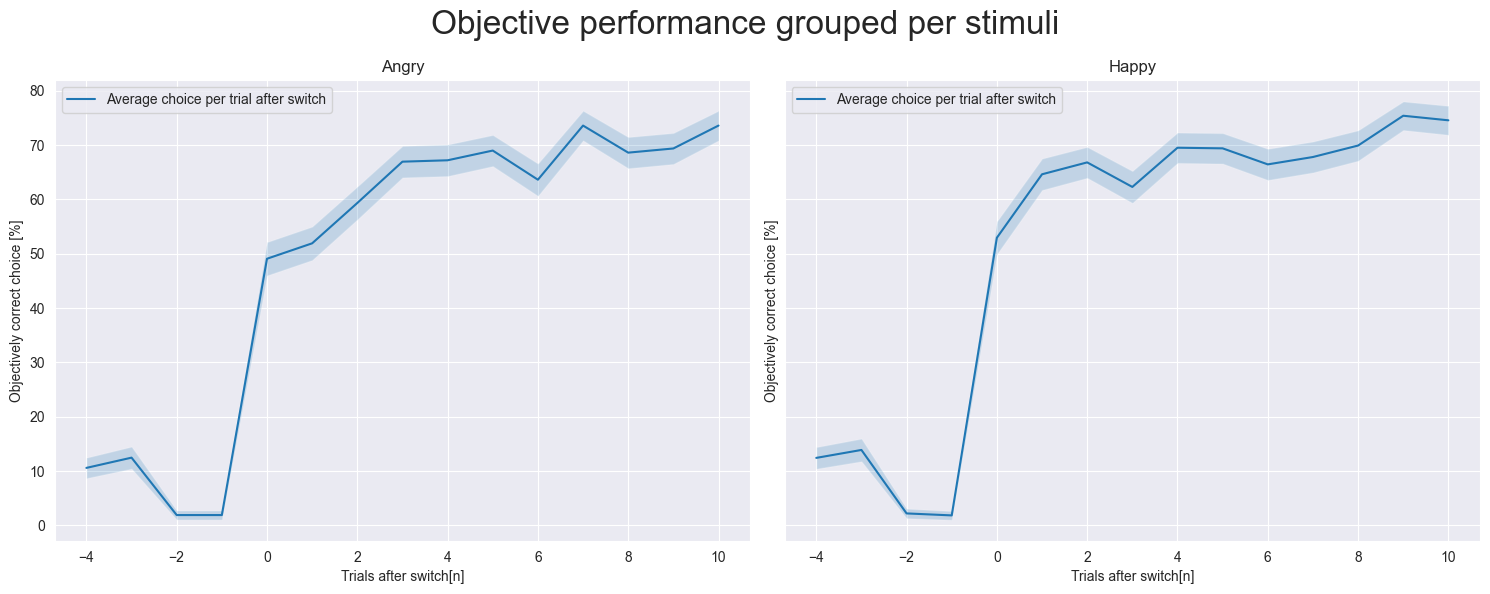

In [972]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped per stimuli', fontsize=24, y=0.982)

stimuli_types_list = ['Angry', 'Happy']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    #axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch[n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_per_stimuli_4-12.pdf'))
plt.show()

# Subplots for incongruent and congruent switches

In [973]:
# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 13))
mapping = {0: 'stimuli_type', 1: 'subject_id', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10, 14: 11, 15: 12}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                 unique_subject_ids,
                                                                 unique_stimuli_types,
                                                                 'congruency',
                                                                 plot_range,
                                                                 mapping)
print(all_switches_dataframe)

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:552: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:552: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/

    stimuli_type  subject_id   congruency    0      1      2      3      4  \
0        sub-001           1  incongruent  100    0.0    0.0    0.0    0.0   
1        sub-001           1  incongruent  100  100.0  100.0  100.0  100.0   
2        sub-001           1  incongruent  100  100.0  100.0    0.0  100.0   
3        sub-001           1    congruent    0    0.0    0.0  100.0    0.0   
4        sub-001           1    congruent    0  100.0  100.0  100.0  100.0   
..           ...         ...          ...  ...    ...    ...    ...    ...   
561      sub-045           3  incongruent  100  100.0    0.0  100.0  100.0   
562      sub-045           3  incongruent    0    0.0    0.0  100.0  100.0   
563      sub-045           3    congruent  100  100.0  100.0  100.0  100.0   
564      sub-045           3    congruent    0  100.0  100.0  100.0  100.0   
565      sub-045           3    congruent    0    0.0  100.0  100.0  100.0   

         5      6      7      8      9     10     11     12  
0

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:552: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:552: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/

               0      1      2      3      4      5      6      7      8  \
congruency                                                                 
incongruent  100    0.0    0.0    0.0    0.0  100.0  100.0    0.0    0.0   
incongruent  100  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0   
incongruent  100  100.0  100.0    0.0  100.0    0.0    0.0    0.0    0.0   
congruent      0    0.0    0.0  100.0    0.0  100.0  100.0  100.0    0.0   
congruent      0  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0   
...          ...    ...    ...    ...    ...    ...    ...    ...    ...   
incongruent  100  100.0    0.0  100.0  100.0  100.0    0.0  100.0    0.0   
incongruent    0    0.0    0.0  100.0  100.0  100.0  100.0  100.0  100.0   
congruent    100  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0   
congruent      0  100.0  100.0  100.0  100.0  100.0  100.0    0.0  100.0   
congruent      0    0.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0   

           

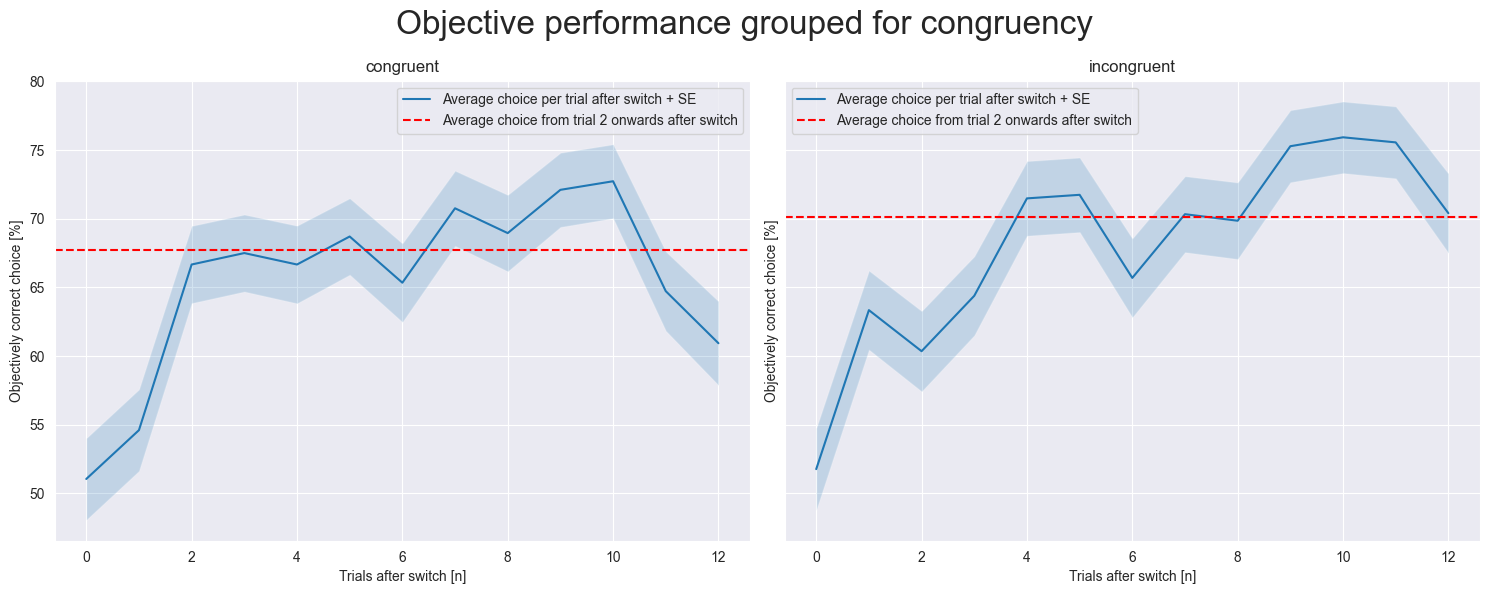

In [974]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('congruency')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_switches_dataframe['congruency'].unique()
print(df)

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_type)
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_congruency.pdf'))
plt.show()

# Subplots for reversal and non-reversal switches

In [975]:
# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 13))
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'all_reversals', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10, 14: 11, 15: 12}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe_separate_reversals(combined_results_dataframe,
                                                                                          unique_subject_ids,
                                                                                          unique_stimuli_types,
                                                                                          plot_range,
                                                                                          mapping)
print(all_switches_dataframe)

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:606: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['all_switches'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:606: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['all_switches'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_ana

    subject_id  stimuli_type  all_reversals    0      1      2      3      4  \
0      sub-001             1            1.0  100    0.0    0.0    0.0    0.0   
1      sub-001             1            1.0    0    0.0    0.0  100.0    0.0   
2      sub-001             1            2.0    0  100.0  100.0  100.0  100.0   
3      sub-001             1            2.0  100  100.0  100.0  100.0  100.0   
4      sub-001             1            1.0  100  100.0  100.0  100.0  100.0   
..         ...           ...            ...  ...    ...    ...    ...    ...   
561    sub-045             3            2.0  100  100.0    0.0  100.0  100.0   
562    sub-045             3            1.0  100  100.0  100.0  100.0  100.0   
563    sub-045             3            2.0    0  100.0  100.0  100.0  100.0   
564    sub-045             3            2.0    0    0.0  100.0  100.0  100.0   
565    sub-045             3            1.0    0    0.0    0.0  100.0  100.0   

         5      6      7      8      9 

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:606: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['all_switches'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:606: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['all_switches'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_ana

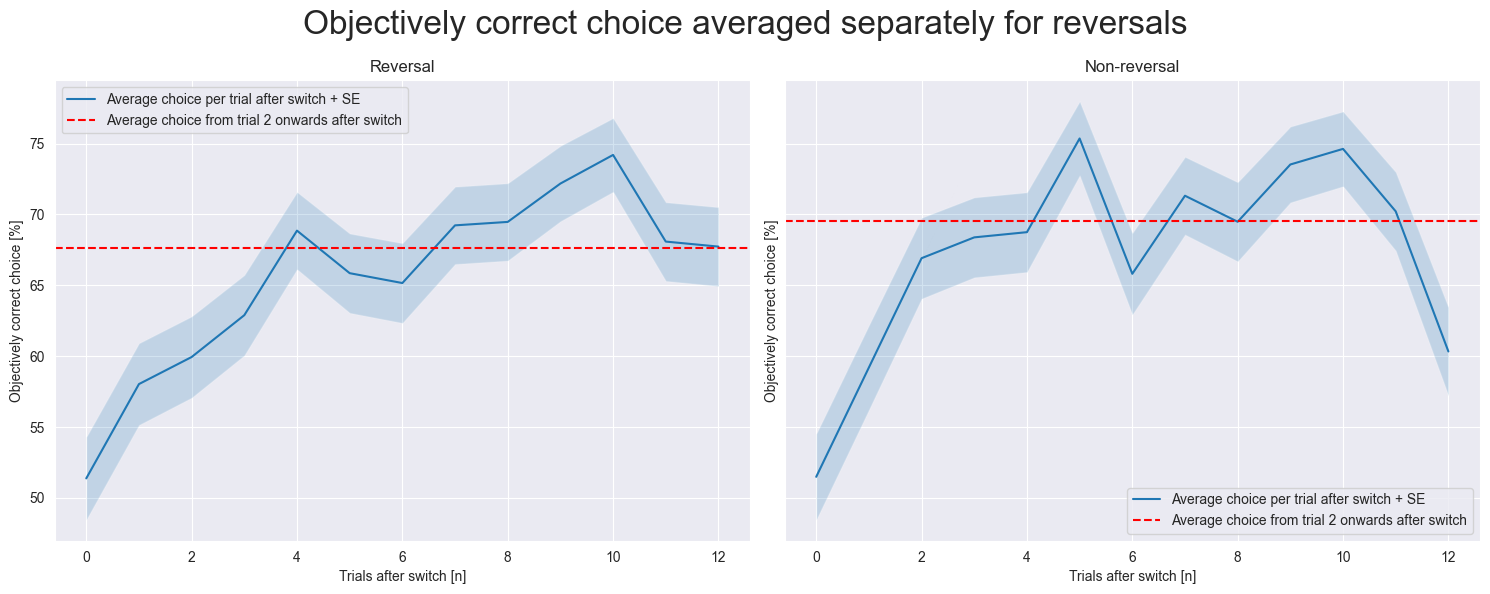

In [976]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('all_reversals')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('all_reversals').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('all_reversals').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False,
                        sharey=True)  # Adjust based on the number of stimuli_types
axs = axs.flatten()  # Flatten to iterate easily

fig.suptitle('Objectively correct choice averaged separately for reversals', fontsize=24, y=0.982)

reversal_list = ['Reversal','Non-reversal']

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--',
                   label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(reversal_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
#plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_for_reversals.pdf'))
plt.show()

# Time before stabilisation
This will be the amount of trials before participants reach an average response of x%

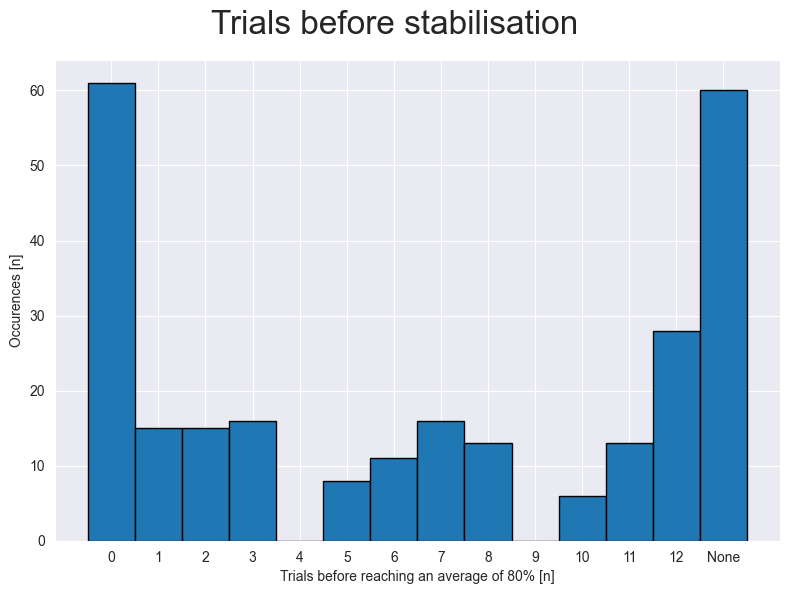

In [977]:
# Set some plotting guidelines
stable_performance = 80
bin_range = [0, 12]
sequence_bin_range = range(min(bin_range), max(bin_range) + 3)
sequence_tick_range = range(min(bin_range), max(bin_range) + 2)

# Create subplots
fig, axes = plt.subplots(figsize=(8, 6), sharey=True)

fig.suptitle('Trials before stabilisation', fontsize=24, y=0.982)

# Bin edges centered around the ticks
bin_edges = [i - 0.5 for i in sequence_bin_range]

# Plot for switch value 1.0
reversal_results = utils.analysis_functions.trials_before_stabilisation(combined_results_dataframe, stable_performance, bin_range, 1.0)
axes.hist(reversal_results['number_of_trials_before_stabilising'], bins=bin_edges, edgecolor='black')
#axes.set_title(reversal_list[0])
axes.set_xlabel(f'Trials before reaching an average of {stable_performance}% [n]')
axes.set_ylabel('Occurences [n]')
axes.set_xticks(sequence_tick_range)

ticks = axes.get_xticks()
tick_labels = axes.get_xticklabels()

# Replace the label at position 13 with None
tick_labels = [label.get_text() if tick != 13 else 'None' for tick, label in zip(ticks, tick_labels)]

# Set the new tick labels
axes.set_xticklabels(tick_labels)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_trials_before_stabilisation.pdf'))
plt.show()

# Chance of a forward response around switch
Here, we plot the chance of a forward response around a switch, hoping to capture a flip in the switch for the four categories:
- happy incongruent > congruent
- angry incongruent > congruent
- happy congruent > incongruent
- angry congruent > incongruent

In [978]:
# First create a new dataframe with the 
bin_range = [-6, 6]
dataframe = utils.analysis_functions.bin_responses_for_congruency(combined_results_dataframe, bin_range) 

#print(dataframe)

[0, 15, 60, 120, 135, 150, 180, 195, 240, 300, 315, 330, 360, 375, 420, 495, 540, 555, 600, 675, 720, 735, 780, 840, 855, 870, 900, 915, 960, 990, 1020, 1065, 1110, 1155, 1170, 1200, 1215, 1230, 1260, 1305, 1380, 1425, 1440, 1470, 1485, 1500, 1530, 1575, 1650, 1695, 1710, 1755, 1800, 1845, 1890, 1920, 1935, 1950, 1980, 2010, 2025, 2040, 2100, 2145, 2190, 2235, 2250, 2265, 2310, 2385, 2430, 2445, 2490, 2550, 2565, 2580, 2610, 2625, 2670, 2700, 2730, 2775, 2790, 2805, 2850, 2925, 2970, 2985, 3030, 3090, 3105, 3120, 3150, 3165, 3210, 3240, 3270, 3315, 3330, 3375, 3420, 3465, 3480, 3484, 3485, 3486, 3488, 3489, 3491, 3495, 3506, 3507, 3509, 3510, 3511, 3541, 3556, 3572, 3576, 3582, 3583, 3587, 3590, 3591, 3592, 3593, 3594, 3596, 3597, 3598, 3601, 3631, 3646, 3661, 3721, 3766, 3811, 3856, 3871, 3901, 3916, 3931, 3961, 4006, 4081, 4126, 4141, 4171, 4186, 4201, 4231, 4276, 4321, 4336, 4381, 4441, 4456, 4471, 4501, 4516, 4561, 4621, 4636, 4651, 4681, 4696, 4741, 4816, 4861, 4876, 4921, 4996, 5

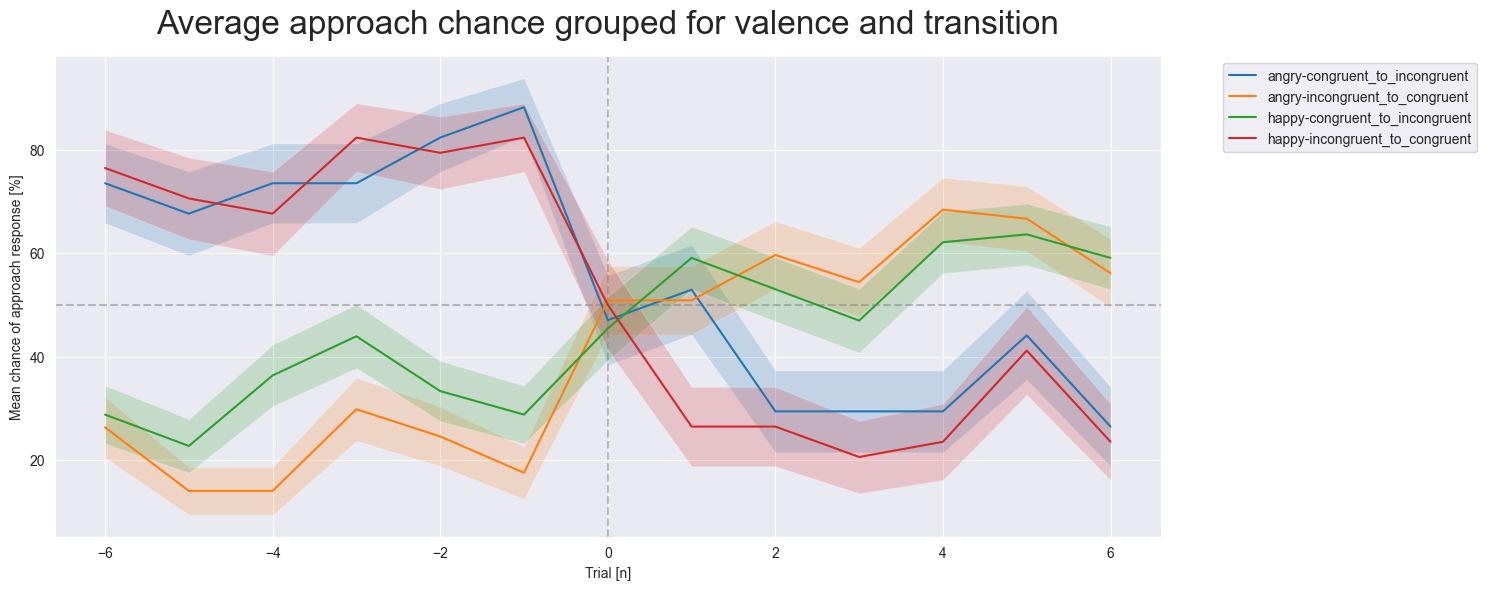

In [979]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_switch', 'emotional_valence', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['emotional_valence'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_switch'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_valence_and_transition.pdf'))
# Show the plot
plt.show()

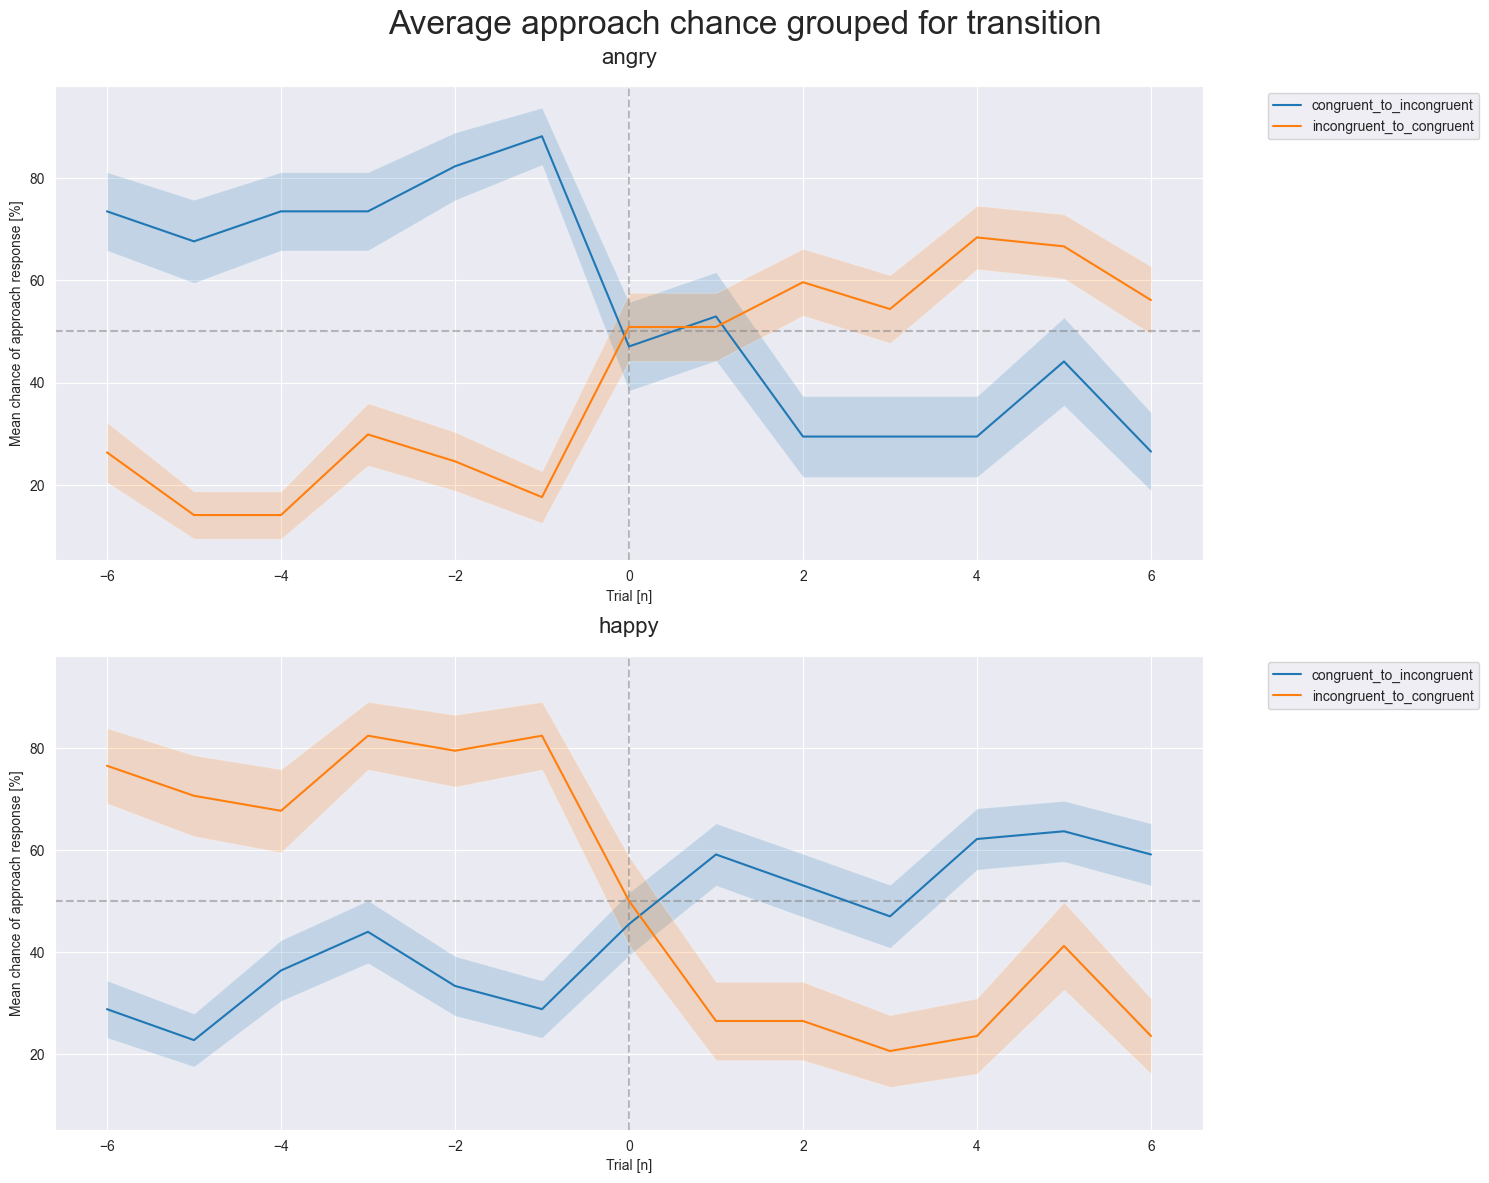

In [980]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_switch'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_valence_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()

# Plot volatile and stable blocks separately

In [981]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 7))
mapping = {0: 'stimuli_type', 1: 'subject_id', 2: 'volatility', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}#, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()


dataframe = utils.analysis_functions.find_switches_in_dataframe(dataframe,
                                                                unique_subject_ids,
                                                                unique_stimuli_types,
                                                                'volatility',
                                                                plot_range,
                                                                mapping)

print(dataframe)

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:215: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['temp_volatility'] = ''
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:216: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:552: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

    stimuli_type  subject_id volatility    0      1      2      3      4  \
0        sub-001           1     stable  100    0.0    0.0    0.0    0.0   
1        sub-001           1     stable    0    0.0    0.0  100.0    0.0   
2        sub-001           1     stable  100  100.0  100.0  100.0  100.0   
3        sub-002           1     stable  100    0.0  100.0  100.0  100.0   
4        sub-002           1     stable    0  100.0    0.0  100.0  100.0   
..           ...         ...        ...  ...    ...    ...    ...    ...   
289      sub-044           3     stable    0    0.0  100.0  100.0  100.0   
290      sub-044           3     stable    0  100.0    0.0    0.0  100.0   
291      sub-045           3     stable  100  100.0    0.0  100.0  100.0   
292      sub-045           3     stable  100  100.0  100.0  100.0  100.0   
293      sub-045           3     stable    0    0.0    0.0  100.0  100.0   

         5      6  
0    100.0  100.0  
1    100.0  100.0  
2    100.0  100.0  
3    10

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:552: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:552: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/

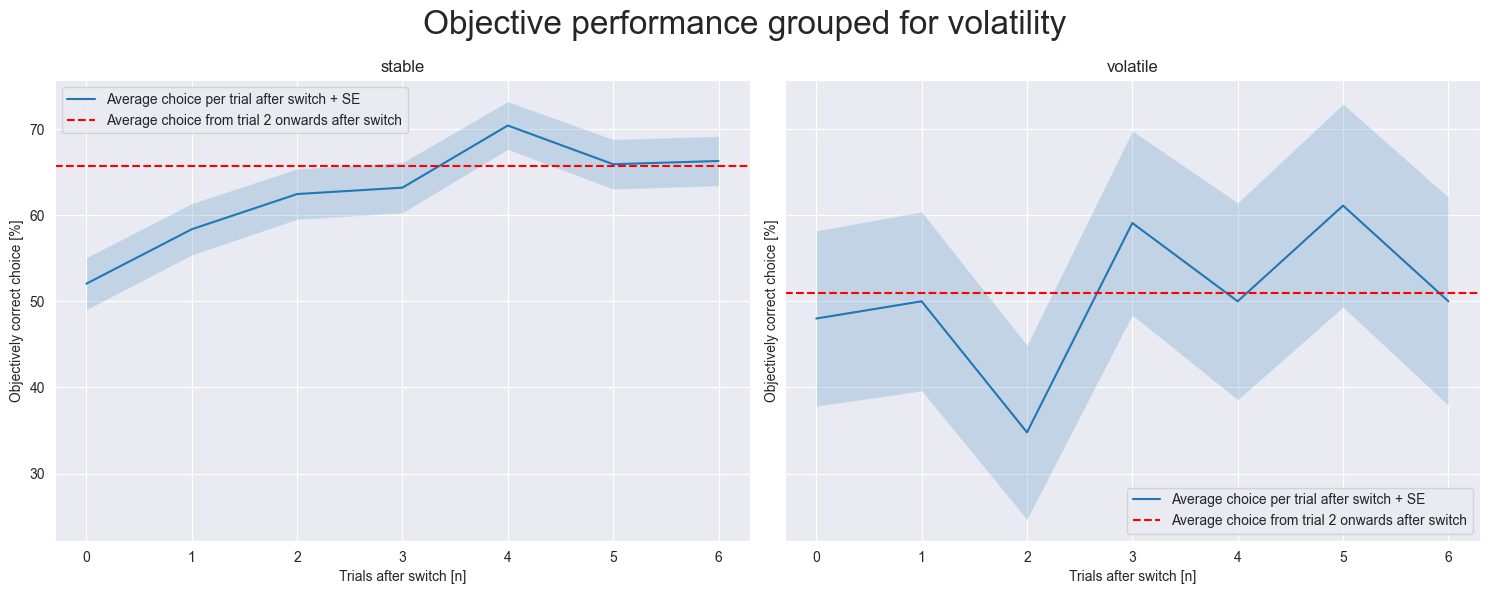

In [982]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe.set_index('volatility')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility.pdf'))
plt.show()

In [983]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Then bin the area around a switch
bin_range = [-6, 6]
dataframe = utils.analysis_functions.bin_responses_for_congruency(dataframe, bin_range, 'volatility')

#print(dataframe)
[0, 29, 59, 66, 74, 80, 87, 94, 100, 130, 158, 166, 171, 178, 186, 193, 199, 228, 255, 261, 267, 281, 287, 295, 301, 333, 363, 370, 378, 384, 390, 397, 404, 435, 463, 471, 477, 485, 493, 500, 506, 536, 564, 570, 576, 583, 591, 597, 605, 641, 668, 673, 681, 688, 709, 737, 765, 772, 778, 784, 798, 803, 834, 866, 873, 879, 884, 889, 897, 903, 909, 939, 967, 973, 981, 988, 996, 1003, 1011, 1039, 1068, 1075, 1082, 1087, 1094, 1100, 1105, 1137, 1166, 1173, 1180, 1186, 1192, 1199, 1205]

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:215: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['temp_volatility'] = ''
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:216: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''


[0, 15, 60, 120, 135, 150, 180, 195, 240, 300, 315, 330, 360, 375, 420, 495, 540, 555, 600, 675, 720, 735, 780, 840, 855, 870, 900, 915, 960, 990, 1020, 1065, 1110, 1155, 1170, 1200, 1215, 1230, 1260, 1305, 1380, 1425, 1440, 1470, 1485, 1500, 1530, 1575, 1650, 1695, 1710, 1755, 1800, 1845, 1890, 1920, 1935, 1950, 1980, 2010, 2025, 2040, 2100, 2145, 2190, 2235, 2250, 2265, 2310, 2385, 2430, 2445, 2490, 2550, 2565, 2580, 2610, 2625, 2670, 2700, 2730, 2775, 2790, 2805, 2850, 2925, 2970, 2985, 3030, 3090, 3105, 3120, 3150, 3165, 3210, 3240, 3270, 3315, 3330, 3375, 3420, 3465, 3480, 3484, 3485, 3486, 3488, 3489, 3491, 3495, 3506, 3507, 3509, 3510, 3511, 3541, 3556, 3572, 3576, 3582, 3583, 3587, 3590, 3591, 3592, 3593, 3594, 3596, 3597, 3598, 3601, 3631, 3646, 3661, 3721, 3766, 3811, 3856, 3871, 3901, 3916, 3931, 3961, 4006, 4081, 4126, 4141, 4171, 4186, 4201, 4231, 4276, 4321, 4336, 4381, 4441, 4456, 4471, 4501, 4516, 4561, 4621, 4636, 4651, 4681, 4695, 4740, 4815, 4860, 4875, 4920, 4995, 5

[0,
 29,
 59,
 66,
 74,
 80,
 87,
 94,
 100,
 130,
 158,
 166,
 171,
 178,
 186,
 193,
 199,
 228,
 255,
 261,
 267,
 281,
 287,
 295,
 301,
 333,
 363,
 370,
 378,
 384,
 390,
 397,
 404,
 435,
 463,
 471,
 477,
 485,
 493,
 500,
 506,
 536,
 564,
 570,
 576,
 583,
 591,
 597,
 605,
 641,
 668,
 673,
 681,
 688,
 709,
 737,
 765,
 772,
 778,
 784,
 798,
 803,
 834,
 866,
 873,
 879,
 884,
 889,
 897,
 903,
 909,
 939,
 967,
 973,
 981,
 988,
 996,
 1003,
 1011,
 1039,
 1068,
 1075,
 1082,
 1087,
 1094,
 1100,
 1105,
 1137,
 1166,
 1173,
 1180,
 1186,
 1192,
 1199,
 1205]

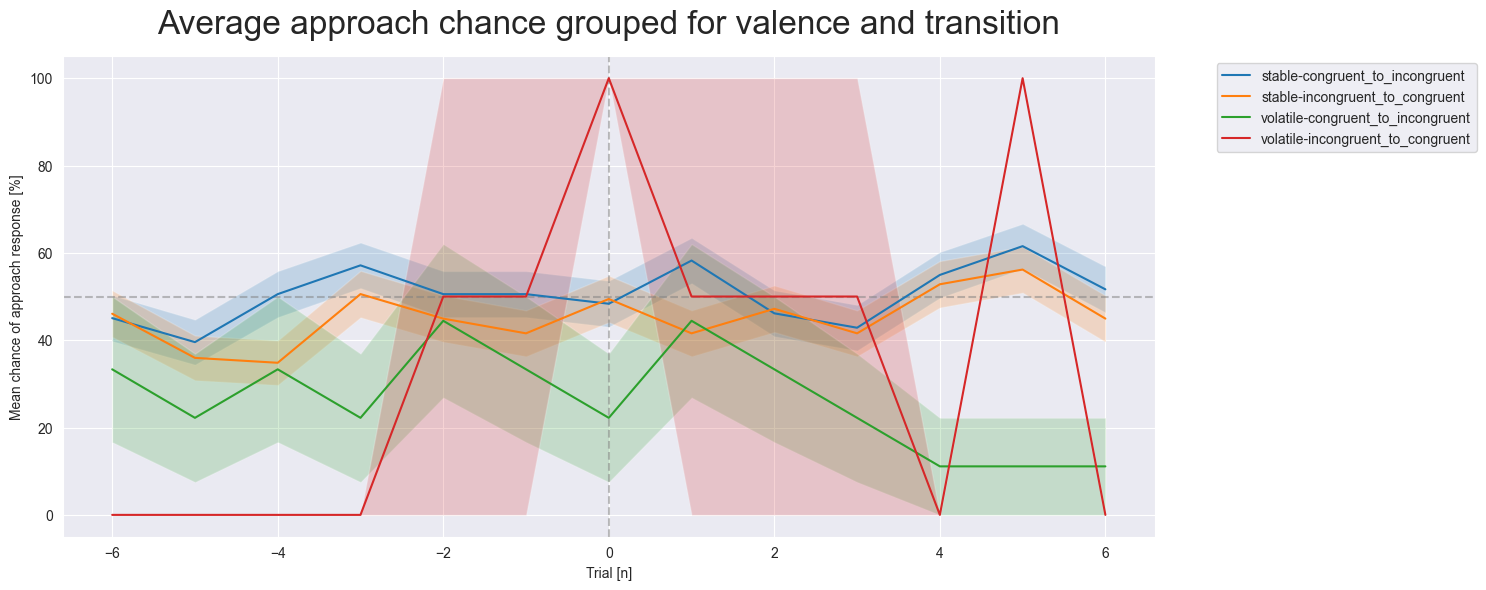

In [984]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_switch', 'volatility', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['volatility'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_switch'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_volatility_and_transition.pdf'))
# Show the plot
plt.show()

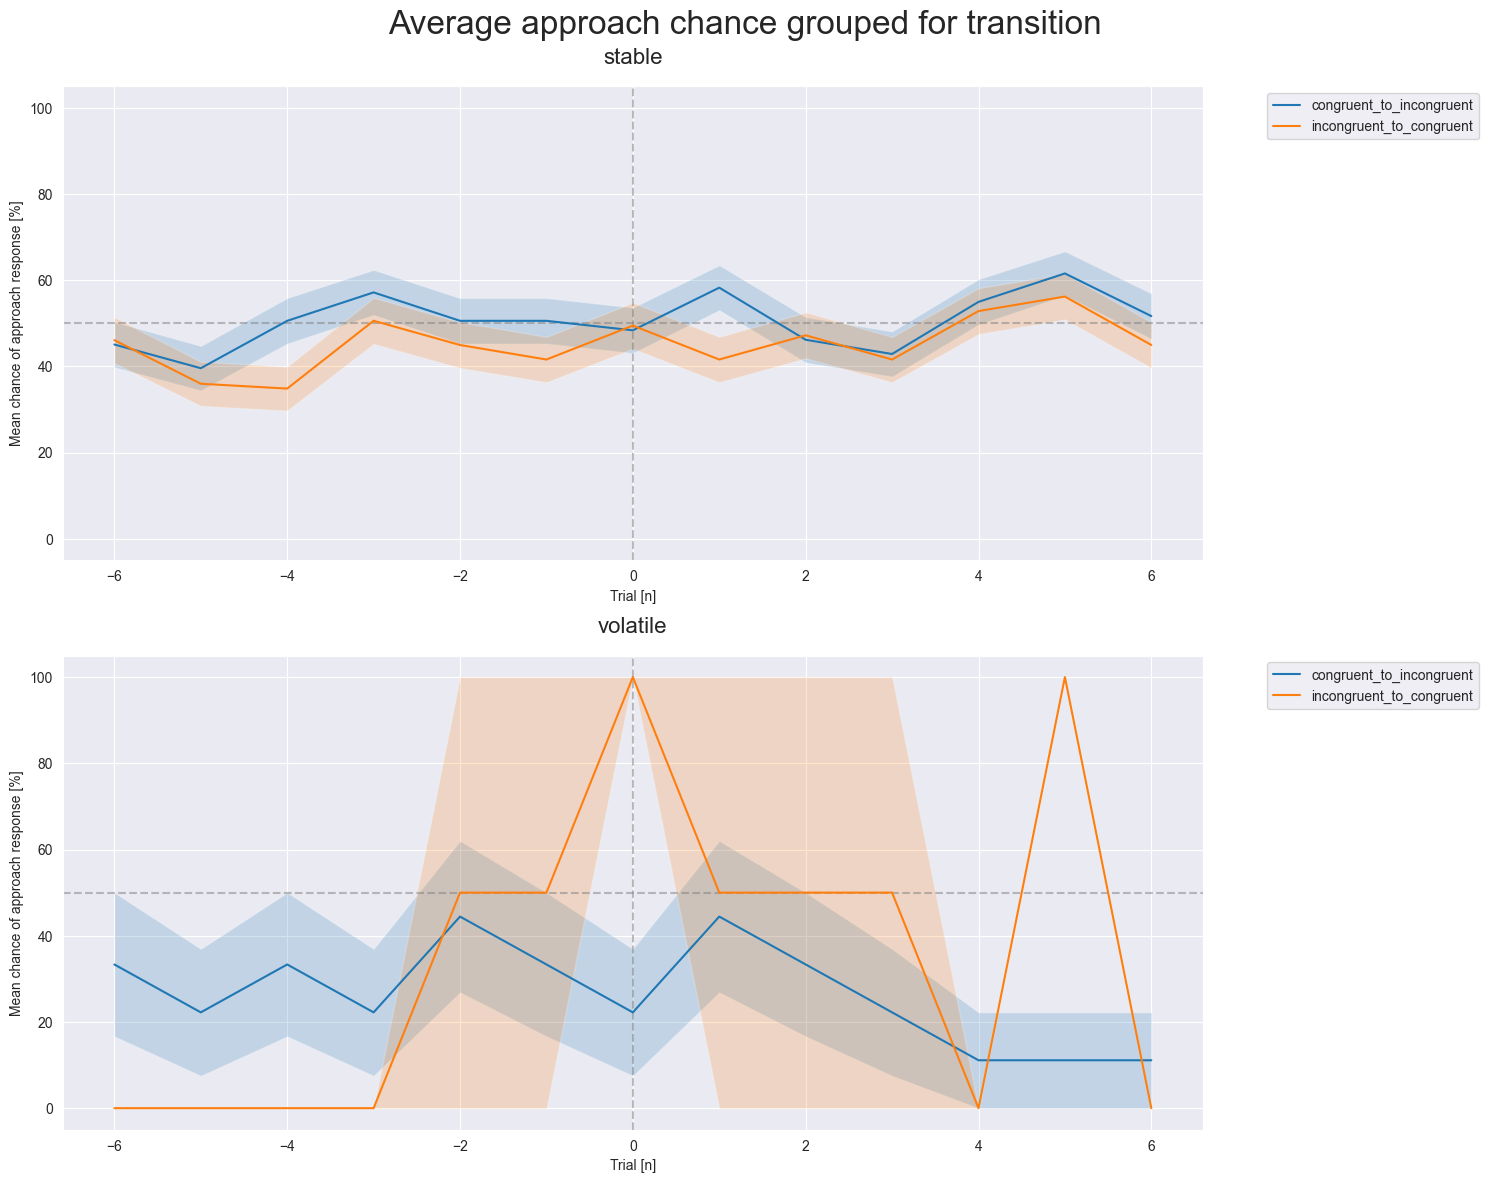

In [985]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_switch'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_volatility_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()